# 뉴스 감성 점수를 입력 feature로 추가한 지정 모델·앙상블 비교

5일 **NLinear+XGBoost**, 20일 **NLinear+DLinear**, 60일 **DLinear**를 비교한다. 각 단일 모델을 **가격·기후·거시 27개 입력**과 **뉴스 1개 추가한 28개 입력**으로 각각 학습한다. 뉴스가 없거나 집계 점수가 0인 날은 27개 입력 모델로 복귀하고, 방향 뉴스가 있는 날만 28개 입력 모델을 사용한다. 앙상블은 모델의 예측 가격을 동일 가중 평균한다. 별도의 뉴스 계수 적합·예측 후 잔차 보정·Naive/Persistence는 없다. 뉴스의 양·음 신호는 입력 값의 의미이며, 출력 가격에 미치는 방향과 크기는 모델이 학습한다.

**동일 조건 비교:** 뉴스 이력이 2022년부터 있으므로 뉴스 없는 모델도 동일한 2022~2023년 학습 표본을 사용한다. 뉴스 결측 때문에 가격 표본을 버리거나 60일 연속 뉴스를 요구하지 않는다. 입력 창은 기존 가격·기후·거시 60거래일이고 뉴스는 관측된 위치에만 들어간다. 이로 인해 이전의 2015~2023년 학습 결과와 직접 비교하면 안 된다. 가격·기후의 과거 관측은 수익률·기후 기준값 산출에 사용하되, 회귀 학습 origin은 두 조건 모두 2022년 이후다.

**선택 순서:** ① 2022년 말까지 정답이 성숙한 표본으로 학습 → ② 2023년 정답으로 설정·뉴스 사용·조합 선택 → ③ 동일한 선택을 고정하고 2023년 말까지 재학습 → ④ 2024~2026년 관측 구간 평가. 모델별 10/30 epoch, XGBoost 100/300 trees를 비교하며 뉴스 유무 두 조건의 2023년 가격 RMSE 평균이 낮은 **공통 설정**을 택한다. 같은 모델의 뉴스 유무 대조는 설정과 표본이 동일하다. 최종 모델 선택 점수는 `RMSE/최저 단일 RMSE + (1−균형 정확도)/(1−최고 단일 균형 정확도)`이며 동률이면 단순 모델·뉴스 없음을 우선한다.

2024~2025년은 이미 살펴본 과거 구간이고 2026년은 9월 25일까지 관측된 성숙 정답만 사용한다. 뉴스는 2026년 소급 분류이므로 당시 실시간 뉴스 예측력을 입증하지 않는다. 이 실험의 선택은 아래 frozen protocol에 저장하며 운영 artifact·DB·배포를 교체하지 않는다. 이전 계수 실험은 `03_5_fixed_ensemble_news.ipynb`에 연구 이력으로 보존한다.

In [1]:
import os, sys, json, hashlib, tempfile, platform, time
from pathlib import Path
for key in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","VECLIB_MAXIMUM_THREADS"):
    os.environ[key]="1"
os.environ.setdefault("MPLCONFIGDIR",str(Path(tempfile.gettempdir())/"coffee-matplotlib"))
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Markdown, display
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/"coffee_service").is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from data_code.fixed_ensemble_news import (PAIRS, SEED, FINAL_CUTOFF, scores, average_prices, align_models,
    load_market, fixed_features, forecast, paired_interval, daily_news_feature)
from coffee_service.news_residual import signal_features, SIGNAL_DEFINITION
from coffee_service.transform import coffee_sessions
FONT={"Darwin":"AppleGothic","Windows":"Malgun Gothic"}.get(platform.system(),"NanumGothic")
assert FONT in {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family":FONT,"axes.unicode_minus":False,"figure.dpi":110,
                    "axes.spines.top":False,"axes.spines.right":False})
def show(frame,digits=4):display(Markdown(frame.to_markdown(index=False,floatfmt=f".{digits}f")))
SOURCE=ROOT/"data/processed/fixed_ensemble_news/sources_20260928"
NEWS=ROOT/"data/jev/sentiment.csv"
inputs=[*sorted(SOURCE.glob("*.parquet")),NEWS,
        ROOT/"data_code/fixed_ensemble_news.py",ROOT/"coffee_service/news_residual.py",
        ROOT/"data_code/single_model_networks.py",ROOT/"coffee_service/transform.py",
        ROOT/"coffee_service/features.py",ROOT/"coffee_service/training.py"]
hashes={str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs}
notebook=json.loads((ROOT/"data_code/03_6_news_feature_ensemble.ipynb").read_text())
code="\n".join("".join(c["source"]) for c in notebook["cells"] if c["cell_type"]=="code")
hashes["notebook_code"]=hashlib.sha256(code.encode()).hexdigest()
versions={name:version(name) for name in ("numpy","pandas","scipy","scikit-learn","torch","xgboost")}
versions["python"]=platform.python_version()
RUN=hashlib.sha256(json.dumps([hashes,versions],sort_keys=True).encode()).hexdigest()[:16]
OUTPUT=ROOT/"data/processed/news_feature_ensemble"/RUN
OUTPUT.mkdir(parents=True,exist_ok=True)
print("연구 결과:",OUTPUT.relative_to(ROOT),"| 신호:",SIGNAL_DEFINITION)

연구 결과: data/processed/news_feature_ensemble/ed374e9c9c0a19c6 | 신호: argmax_direction_times_relevance_confidence


## 1. 가격·기후·거시경제 입력 확인

자료 경로는 과거 원본을 보존한 연구용 복사본이다. 2025년까지의 가격/거시는 기존 snapshot, 이후는 `jev_live`의 추가 관측 자료를 이어 붙였다. NASA 6지역의 누락된 2026-01-31~09-25 관측은 기존 `ingestion.fetch_weather`로 추가 수집했다. 새 API 요청 없이 아래 셀을 재실행할 수 있다. 기후 공개 지연 4일, ALFRED 공개일+1일 규칙을 유지한다. NASA 자료의 실제 과거 배포 snapshot을 보유한 것은 아니다.

**수집한 모든 컬럼을 쓰지는 않는다.** 기존 27개 입력을 유지해 이전 단일 모델 비교와 연결한다. 6지역 강수·평균기온은 사용하고, 최저기온 기반 브라질 서리 6개는 최초 학습에서 상수라 제외한다. 최고기온·습도는 기존 피처 설계에 없으며, 광의 달러지수와 COT는 기존 시점 계약 문제로 제외했다. 이것은 모든 후보 변수를 최적화했다는 뜻이 아니다.

이번 추가 입력은 `news_sentiment` 하나다. 27개 공통 피처 목록은 이전 비교에서 고정한 목록이며 뉴스 유무별로 따로 선택하지 않는다.

In [2]:
sources,sessions,prices=load_market(SOURCE)
FEATURES,constant=fixed_features(sources,sessions)
assert len(FEATURES)==27
show(pd.DataFrame([{"자료":name,"시작":d.date.min().date(),"끝":d.date.max().date(),"행 수":len(d)} for name,d in sources.items()]),0)
feature_audit=pd.DataFrame([
    {"입력":"가격","상태":"사용","내용":"1/5/20일 로그수익률·20일 변동성","개수":4},
    {"입력":"거시경제","상태":"사용","내용":"ALFRED DEXBZUS 환율·DFF 금리·DCOILWTICO 유가의 20일 변화","개수":3},
    {"입력":"6지역 기후","상태":"사용","내용":"강수 편차·평균기온 편차·가뭄","개수":18},
    {"입력":"달력","상태":"사용","내용":"월 sin/cos","개수":2},
    {"입력":"브라질 최저기온 파생","상태":"제외: 최초 학습 상수","내용":"서리·가뭄×서리","개수":6},
    {"입력":"NASA 최고기온·습도","상태":"미사용","내용":"기존 피처 정의에 없음","개수":12},
    {"입력":"DTWEXBGS·COT","상태":"미사용","내용":"기존 공개 시점/소급 자료 계약의 제한","개수":2}])
show(feature_audit,0)
print("사용 피처:",FEATURES,"\n상수 제외:",constant)
print("가격 관측 최종일:",prices.close.dropna().index.max().date())

| 자료                    | 시작       | 끝         |   행 수 |
|:------------------------|:-----------|:-----------|--------:|
| coffee                  | 2014-07-01 | 2026-09-25 |    3083 |
| alfred_dexbzus          | 2014-07-01 | 2026-09-18 |    3189 |
| alfred_dff              | 2014-07-01 | 2026-09-24 |    4469 |
| alfred_dcoilwtico       | 2014-07-01 | 2026-09-22 |    3191 |
| weather_br_sul_minas    | 2014-06-01 | 2026-09-25 |    4500 |
| weather_br_cerrado      | 2014-06-01 | 2026-09-25 |    4500 |
| weather_br_alta_mogiana | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_huila        | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_caldas       | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_antioquia    | 2014-06-01 | 2026-09-25 |    4500 |

| 입력                 | 상태                 | 내용                                                     |   개수 |
|:---------------------|:---------------------|:---------------------------------------------------------|-------:|
| 가격                 | 사용                 | 1/5/20일 로그수익률·20일 변동성                          |      4 |
| 거시경제             | 사용                 | ALFRED DEXBZUS 환율·DFF 금리·DCOILWTICO 유가의 20일 변화 |      3 |
| 6지역 기후           | 사용                 | 강수 편차·평균기온 편차·가뭄                             |     18 |
| 달력                 | 사용                 | 월 sin/cos                                               |      2 |
| 브라질 최저기온 파생 | 제외: 최초 학습 상수 | 서리·가뭄×서리                                           |      6 |
| NASA 최고기온·습도   | 미사용               | 기존 피처 정의에 없음                                    |     12 |
| DTWEXBGS·COT         | 미사용               | 기존 공개 시점/소급 자료 계약의 제한                     |      2 |

사용 피처: ['return_1', 'return_5', 'return_20', 'volatility_20', 'brl_change_20', 'rate_change_20', 'oil_change_20', 'br_sul_minas_rain_anomaly', 'br_sul_minas_temp_anomaly', 'br_sul_minas_drought', 'br_cerrado_rain_anomaly', 'br_cerrado_temp_anomaly', 'br_cerrado_drought', 'br_alta_mogiana_rain_anomaly', 'br_alta_mogiana_temp_anomaly', 'br_alta_mogiana_drought', 'co_huila_rain_anomaly', 'co_huila_temp_anomaly', 'co_huila_drought', 'co_caldas_rain_anomaly', 'co_caldas_temp_anomaly', 'co_caldas_drought', 'co_antioquia_rain_anomaly', 'co_antioquia_temp_anomaly', 'co_antioquia_drought', 'month_sin', 'month_cos'] 
상수 제외: ['br_sul_minas_frost', 'br_sul_minas_drought_frost', 'br_cerrado_frost', 'br_cerrado_drought_frost', 'br_alta_mogiana_frost', 'br_alta_mogiana_drought_frost']
가격 관측 최종일: 2026-09-25


## 2. 뉴스가 있을 때만 사용하는 s_i feature

` s_i = direction_i × relevance_i × confidence_i `. bullish 단독 최대는 +1, bearish 단독 최대는 −1, neutral/uncertain 또는 동률은 0이다. 예시 기사 점수는 `−1 × 0.52 × 0.22 = −0.1144`다.

기사를 공개·수정·선정 완료 시각 이후 **처음 도달하는 거래일의 UTC 23:00 연구 기준시각**에 배정한다. 그 거래일에 새로 이용 가능한 기사들의 `tanh(sum(s_i))`가 **news_sentiment** 하나다. 뉴스가 없는 날은 NaN이며 감쇠·이전 값 복사로 신호를 생성하지 않는다. 실제 분류 시각을 기준으로 한 live 자료와 소급 research 자료를 분리한다.

고정 크기의 모델 입력을 만들 때만 결측 위치를 0으로 마스킹한다. 뉴스는 이미 [−1,1] 점수이므로 평균을 빼지 않아 중립 0을 보존한다. `news_present`는 분석의 존재 여부를 기록하고 모델 입력에는 추가하지 않는다. **예측 기준일에 뉴스가 없거나 점수가 0이면 27개 입력 모델의 예측을 그대로 사용한다.** 분석이 있지만 neutral/uncertain인 0과 분석 자체가 없는 NaN은 감사 기록에서 구분한다. 신호가 있는 날에도 가격에 미치는 방향·크기는 모델이 학습하므로 예전의 방향 고정 잔차 보정과 다르다.

UTC 23:00은 저장소의 기존 뉴스 시점 계약이며 거래소 마감 시각이 아니다. 기준일 종가를 관측한 뒤의 예측으로 해석하며 그 종가에 실제 주문할 수 있었다고 가정하지 않는다.

In [3]:
news=pd.read_csv(NEWS).loc[lambda d:d.selected_for_research.eq(True)].copy()
assert news.is_latest_analysis.all() and not news.content_hash.duplicated().any()
probcols=["p_bullish","p_bearish","p_neutral","p_uncertain"]
prob=news[probcols].to_numpy(float)
assert np.isfinite(prob).all() and ((prob>=0)&(prob<=1)).all()
np.testing.assert_allclose(prob.sum(axis=1),1,atol=.02,rtol=0)
winners=np.isclose(prob,prob.max(axis=1,keepdims=True),atol=1e-8,rtol=0)
news["direction"]=np.where((winners.sum(axis=1)==1)&winners[:,0],1,
    np.where((winners.sum(axis=1)==1)&winners[:,1],-1,0))
news["article_signal"]=news.direction*news.relevance*news.confidence
news["year"]=pd.to_datetime(news.selection_date).dt.year
news_audit=news.groupby("year").agg(기사수=("analysis_id","size"),영신호=("article_signal",lambda s:int(s.eq(0).sum())),
    상승신호=("article_signal",lambda s:int(s.gt(0).sum())),하락신호=("article_signal",lambda s:int(s.lt(0).sum())),제목만=("title_only","sum")).reset_index().rename(columns={"year":"연도"})
show(news_audit,0)
records=[]
for raw in news.to_dict("records"):
    row={k:None if pd.isna(v) else v for k,v in raw.items()}
    event=max(pd.Timestamp(row["event_at"]),pd.Timestamp(row["published_at"]))
    visible=max(event,pd.Timestamp(row["research_available_at"]),pd.Timestamp(row["modified_at"]) if row["modified_at"] else event)
    row["event_at"]=event.isoformat();row["selection_available_at"]=visible.isoformat();records.append(row)
news_sessions=sessions[sessions>=pd.Timestamp("2022-01-01")]
daily=daily_news_feature(records,news_sessions,availability="research")
live_daily=daily_news_feature(records,news_sessions,availability="live")
news_feature=daily.news_sentiment
assert not live_daily.news_present.any()
assert news_feature.dropna().between(-1,1).all()
assert daily.news_present.eq(news_feature.notna()).all()
assert news_feature.loc[~daily.news_present].isna().all()
print("거래일별 분석 있음/없음:",daily.news_present.value_counts().to_dict())
print("분석은 있지만 점수 0인 거래일:",int((daily.news_present & news_feature.eq(0)).sum()))
print("실제 분석 이용 시각:",news.available_at.min(),"~",news.available_at.max())

def route_news(individual):
    """방향 뉴스가 없는 날에는 같은 설정의 기본 모델 예측을 그대로 사용한다."""
    output=[]
    for _,group in individual.groupby(["horizon","model","setting"]):
        base=group.loc[group["mode"].eq("뉴스 없음")].sort_values("origin_date").set_index("origin_date")
        augmented=group.loc[group["mode"].eq("뉴스 feature")].sort_values("origin_date").set_index("origin_date")
        columns=["target_date","actual_return","current_price","news_present"]
        pd.testing.assert_frame_equal(base[columns],augmented[columns],check_exact=True)
        signal=news_feature.reindex(base.index)
        active=signal.notna() & signal.ne(0)
        for part in (base,augmented):
            part["raw_model_return"]=part.predicted_return
            part["news_score"]=signal
            part["news_used"]=False
        augmented["news_used"]=active
        augmented.loc[~active,"predicted_return"]=base.loc[~active,"predicted_return"]
        np.testing.assert_array_equal(augmented.loc[~active,"predicted_return"],base.loc[~active,"predicted_return"])
        output.extend([base.reset_index(),augmented.reset_index()])
    return pd.concat(output,ignore_index=True)


|   연도 |   기사수 |   영신호 |   상승신호 |   하락신호 |   제목만 |
|-------:|---------:|---------:|-----------:|-----------:|---------:|
|   2022 |      189 |      151 |         30 |          8 |      189 |
|   2023 |      213 |      174 |         25 |         14 |      213 |
|   2024 |      256 |      187 |         47 |         22 |      256 |
|   2025 |      383 |      251 |         83 |         49 |      383 |
|   2026 |      404 |      191 |        120 |         93 |      280 |

거래일별 분석 있음/없음: {True: 993, False: 195}
분석은 있지만 점수 0인 거래일: 613
실제 분석 이용 시각: 2026-09-26T09:12:42.298569Z ~ 2026-09-27T02:21:29.482870Z


## 3. 2022년 학습, 2023년 설정·모델 선택

두 입력 조건 모두 동일한 날짜의 2022년 성숙 정답으로 학습한다. 2023년 말 이후 정답은 Validation에 들어가지 않는다. 표준화와 기후 기준값은 2022년까지만 사용한다. 설정을 선택한 뒤 단일 모델과 지정 평균을 비교한다. 같은 Validation으로 설정과 후보를 고르는 탐색적 절차이며 별도 내부 검증을 추가한 것은 아니다.

In [4]:
model_dir=OUTPUT/"models";model_dir.mkdir(exist_ok=True)
MODES={False:"뉴스 없음",True:"뉴스 feature"}
validation_parts=[]
for h,members in PAIRS.items():
    for name in members:
        for setting in ((100,300) if name=="XGBoost" else (10,30)):
            for use_news in (False,True):
                part=forecast(sources,sessions,FEATURES,h,name,setting,
                    model_dir/f"validation_{name}_{h}_{setting}_{int(use_news)}",
                    news_feature=news_feature,use_news=use_news,cutoff="2022-12-31",evaluation_end="2023-12-31")
                part["mode"]=MODES[use_news];validation_parts.append(part)
    print(f"{h}일 2023년 Validation 예측 완료",flush=True)
validation_individual=route_news(pd.concat(validation_parts,ignore_index=True))
assert validation_individual.origin_date.dt.year.eq(2023).all()
assert validation_individual.target_date.le(FINAL_CUTOFF).all()
assert validation_individual.train_cutoff.eq(pd.Timestamp("2022-12-31")).all()
setting_rows=[]
for (h,name,setting,mode),g in validation_individual.groupby(["horizon","model","setting","mode"]):
    setting_rows.append({"지평":h,"모델":name,"설정":int(setting),"입력":mode,**scores(g,g.predicted_return)})
setting_metrics=pd.DataFrame(setting_rows)
settings={}
for (h,name),g in setting_metrics.groupby(["지평","모델"]):
    common=g.groupby("설정")["가격 RMSE"].mean().sort_values(kind="stable")
    settings[int(h),name]=int(common.index[0])
show(setting_metrics)
print("뉴스 유무 공통 설정:",settings)
def candidates(individual):
    output=[]
    for h,members in PAIRS.items():
        groups={name:(name,) for name in members}
        if len(members)>1:groups[" + ".join(members)]=members
        references=[]
        for use_news,mode in MODES.items():
            source=individual.loc[individual.horizon.eq(h)&individual["mode"].eq(mode)]
            r,p=align_models(source,members);references.append(r)
            for name,group in groups.items():
                signal=news_feature.reindex(r.index)
                output.append(r.assign(horizon=h,model=name,mode=mode,members=len(group),
                    news_present=signal.notna(),news_used=(signal.notna()&signal.ne(0)) if use_news else False,
                    predicted_return=average_prices(p[list(group)])).reset_index())
        pd.testing.assert_frame_equal(*references,check_exact=True)
    return pd.concat(output,ignore_index=True)
chosen_validation=pd.concat([validation_individual.loc[validation_individual.horizon.eq(h)&
    validation_individual.model.eq(name)&validation_individual.setting.eq(setting)]
    for (h,name),setting in settings.items()],ignore_index=True)
validation_forecasts=candidates(chosen_validation)
validation_rows=[]
for (h,name,mode),g in validation_forecasts.groupby(["horizon","model","mode"]):
    validation_rows.append({"지평":h,"모델":name,"입력":mode,"구성원 수":int(g.members.iloc[0]),**scores(g,g.predicted_return)})
validation=pd.DataFrame(validation_rows)
selected_rows=[]
for h,g in validation.groupby("지평"):
    singles=g.loc[g["구성원 수"].eq(1)]
    rmse_reference=singles["가격 RMSE"].min()
    error_reference=1-singles["균형 정확도 (%)"].max()/100
    assert error_reference>0
    g=g.copy();g["선택 점수"]=g["가격 RMSE"]/rmse_reference+(1-g["균형 정확도 (%)"]/100)/error_reference
    g["뉴스 순서"]=g["입력"].map({"뉴스 없음":0,"뉴스 feature":1})
    selected_rows.append(g.sort_values(["선택 점수","가격 RMSE","구성원 수","뉴스 순서","모델"]).iloc[0].to_dict())
selection=pd.DataFrame(selected_rows)
show(validation);show(selection)
protocol={"method":"news_as_one_input_feature","signal_definition":SIGNAL_DEFINITION,
    "daily_aggregation":"tanh(sum(s_i newly available since previous session UTC 23:00 cutoff))",
    "missing_news":"masked input; fallback to matching base forecast when missing or score zero","features":FEATURES,
    "news_feature":"news_sentiment","seed":SEED,"hashes":hashes,"versions":versions,
    "train_origins_from":"2022-01-01","selection_cutoff":"2023-12-31",
    "settings":[{"horizon":h,"model":name,"setting":setting} for (h,name),setting in settings.items()],
    "selected":selection[["지평","모델","입력"]].to_dict("records")}
serialized=json.dumps(protocol,ensure_ascii=False,indent=2,allow_nan=False)
protocol_path=OUTPUT/"frozen_protocol.json"
if protocol_path.exists():assert protocol_path.read_text()==serialized,"고정 선택 충돌"
else:protocol_path.write_text(serialized)
print("평가 전에 입력/설정/선택을 고정했습니다.")

5일 2023년 Validation 예측 완료


20일 2023년 Validation 예측 완료


60일 2023년 Validation 예측 완료


|   지평 | 모델    |   설정 | 입력         |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|:--------|-------:|:-------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|      5 | NLinear |     10 | 뉴스 feature |    245 |      9.3914 |        0.0543 |           51.0204 |           51.2838 |           39.4958 |
|      5 | NLinear |     10 | 뉴스 없음    |    245 |      9.3616 |        0.0542 |           51.4286 |           51.6573 |           40.3361 |
|      5 | NLinear |     30 | 뉴스 feature |    245 |     13.2176 |        0.0760 |           50.6122 |           51.2605 |           26.0504 |
|      5 | NLinear |     30 | 뉴스 없음    |    245 |     13.1267 |        0.0756 |           51.0204 |           51.6573 |           26.0504 |
|      5 | XGBoost |    100 | 뉴스 feature |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |
|      5 | XGBoost |    100 | 뉴스 없음    |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |
|      5 | XGBoost |    300 | 뉴스 feature |    245 |      8.7078 |        0.0504 |           52.2449 |           52.3810 |           42.8571 |
|      5 | XGBoost |    300 | 뉴스 없음    |    245 |      8.7114 |        0.0504 |           52.6531 |           52.7778 |           42.8571 |
|     20 | DLinear |     10 | 뉴스 feature |    230 |     17.0218 |        0.0996 |           49.1304 |           51.0985 |           94.1667 |
|     20 | DLinear |     10 | 뉴스 없음    |    230 |     17.1652 |        0.1006 |           50.0000 |           52.0076 |           94.1667 |
|     20 | DLinear |     30 | 뉴스 feature |    230 |     17.8098 |        0.1041 |           38.6957 |           39.3561 |           75.8333 |
|     20 | DLinear |     30 | 뉴스 없음    |    230 |     17.9076 |        0.1048 |           38.6957 |           39.3939 |           76.6667 |
|     20 | NLinear |     10 | 뉴스 feature |    230 |     19.1204 |        0.1144 |           53.0435 |           53.1818 |           50.0000 |
|     20 | NLinear |     10 | 뉴스 없음    |    230 |     19.1401 |        0.1146 |           52.1739 |           52.3864 |           52.5000 |
|     20 | NLinear |     30 | 뉴스 feature |    230 |     25.9687 |        0.1574 |           52.1739 |           51.3636 |           30.0000 |
|     20 | NLinear |     30 | 뉴스 없음    |    230 |     25.9980 |        0.1578 |           52.1739 |           51.3636 |           30.0000 |
|     60 | DLinear |     10 | 뉴스 feature |    190 |     28.8576 |        0.1719 |           52.1053 |           49.1533 |           90.9091 |
|     60 | DLinear |     10 | 뉴스 없음    |    190 |     29.0902 |        0.1735 |           51.5789 |           48.5071 |           93.1818 |
|     60 | DLinear |     30 | 뉴스 feature |    190 |     29.3770 |        0.1742 |           55.2632 |           53.1083 |           76.1364 |
|     60 | DLinear |     30 | 뉴스 없음    |    190 |     29.5303 |        0.1753 |           55.7895 |           53.5985 |           76.1364 |

뉴스 유무 공통 설정: {(5, 'NLinear'): 10, (5, 'XGBoost'): 100, (20, 'DLinear'): 10, (20, 'NLinear'): 10, (60, 'DLinear'): 10}


|   지평 | 모델              | 입력         |   구성원 수 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|:------------------|:-------------|------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|      5 | NLinear           | 뉴스 feature |           1 |    245 |      9.3914 |        0.0543 |           51.0204 |           51.2838 |           39.4958 |
|      5 | NLinear           | 뉴스 없음    |           1 |    245 |      9.3616 |        0.0542 |           51.4286 |           51.6573 |           40.3361 |
|      5 | NLinear + XGBoost | 뉴스 feature |           2 |    245 |      8.8471 |        0.0511 |           51.8367 |           52.0308 |           41.1765 |
|      5 | NLinear + XGBoost | 뉴스 없음    |           2 |    245 |      8.8385 |        0.0511 |           52.2449 |           52.4276 |           41.1765 |
|      5 | XGBoost           | 뉴스 feature |           1 |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |
|      5 | XGBoost           | 뉴스 없음    |           1 |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |
|     20 | DLinear           | 뉴스 feature |           1 |    230 |     17.0218 |        0.0996 |           49.1304 |           51.0985 |           94.1667 |
|     20 | DLinear           | 뉴스 없음    |           1 |    230 |     17.1652 |        0.1006 |           50.0000 |           52.0076 |           94.1667 |
|     20 | NLinear           | 뉴스 feature |           1 |    230 |     19.1204 |        0.1144 |           53.0435 |           53.1818 |           50.0000 |
|     20 | NLinear           | 뉴스 없음    |           1 |    230 |     19.1401 |        0.1146 |           52.1739 |           52.3864 |           52.5000 |
|     20 | NLinear + DLinear | 뉴스 feature |           2 |    230 |     17.4240 |        0.1026 |           44.7826 |           45.4924 |           70.8333 |
|     20 | NLinear + DLinear | 뉴스 없음    |           2 |    230 |     17.5072 |        0.1032 |           46.0870 |           46.8561 |           70.8333 |
|     60 | DLinear           | 뉴스 feature |           1 |    190 |     28.8576 |        0.1719 |           52.1053 |           49.1533 |           90.9091 |
|     60 | DLinear           | 뉴스 없음    |           1 |    190 |     29.0902 |        0.1735 |           51.5789 |           48.5071 |           93.1818 |

|   지평 | 모델    | 입력         |   구성원 수 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   선택 점수 |   뉴스 순서 |
|-------:|:--------|:-------------|------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|------------:|------------:|
|      5 | XGBoost | 뉴스 feature |           1 |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |      2.0000 |           1 |
|     20 | DLinear | 뉴스 없음    |           1 |    230 |     17.1652 |        0.1006 |           50.0000 |           52.0076 |           94.1667 |      2.0335 |           0 |
|     60 | DLinear | 뉴스 feature |           1 |    190 |     28.8576 |        0.1719 |           52.1053 |           49.1533 |           90.9091 |      2.0000 |           1 |

평가 전에 입력/설정/선택을 고정했습니다.


## 4. 2022~2023년 재학습 후 2024~2026년 평가

가격 모델 자체가 27개 또는 28개 입력으로 학습된다. 뉴스 없는 조건도 같은 2022~2023년 origin을 사용한다. 각 모델의 학습 가중치·표준화·기후 기준값을 2023년 말에 고정하며 평가 기간에 다시 맞추지 않는다. 저장 모델을 다시 읽어 예측이 같은지 확인한다. 연도별 수치는 예측 기준일의 연도다.

In [5]:
assert protocol_path.read_text()==serialized
parts=[]
for (h,name),setting in settings.items():
    for use_news,mode in MODES.items():
        part=forecast(sources,sessions,FEATURES,h,name,setting,
            model_dir/f"evaluation_{name}_{h}_{setting}_{int(use_news)}",
            news_feature=news_feature,use_news=use_news,cutoff=FINAL_CUTOFF)
        part["mode"]=mode;parts.append(part)
    print(f"{h}일 {name}: 뉴스 유무 재학습·평가 완료",flush=True)
individual=route_news(pd.concat(parts,ignore_index=True))
forecasts=candidates(individual)
assert individual.train_cutoff.eq(FINAL_CUTOFF).all()
assert forecasts.origin_date.dt.year.isin([2024,2025,2026]).all()
metric_rows=[]
for (h,name,mode),g in forecasts.groupby(["horizon","model","mode"]):
    choice=selection.loc[selection["지평"].eq(h)].iloc[0]
    chosen=name==choice["모델"] and mode==choice["입력"]
    for year,part in [("전체",g),*[(str(y),g.loc[g.origin_date.dt.year.eq(y)]) for y in (2024,2025,2026)]]:
        if part.empty:continue
        metric_rows.append({"연도":year,"지평":h,"모델":name,"입력":mode,"Validation 선택":chosen,
            "예측 시작":part.origin_date.min().date(),"예측 끝":part.origin_date.max().date(),
            "정답 끝":part.target_date.max().date(),"뉴스 있는 날":int(part.news_present.sum()),
            "뉴스 모델 적용일":int(part.news_used.sum()),**scores(part,part.predicted_return)})
metrics=pd.DataFrame(metric_rows)
show(metrics.loc[metrics["연도"].eq("전체")])
show(metrics.loc[metrics["Validation 선택"]&~metrics["연도"].eq("전체")])
input_audit=[]
for (h,name),setting in settings.items():
    for use_news,mode in MODES.items():
        state=np.load(model_dir/f"evaluation_{name}_{h}_{setting}_{int(use_news)}.npz")
        assert state["features"].tolist()==FEATURES+(["news_sentiment"] if use_news else [])
        input_audit.append({"지평":h,"모델":name,"입력":mode,"입력 수":len(state["features"]),
            "학습 종료":str(state["train_cutoff"]),"학습 표본":int(state["train_rows"]),"뉴스 컬럼 수":int("news_sentiment" in state["features"])})
show(pd.DataFrame(input_audit),0)

5일 NLinear: 뉴스 유무 재학습·평가 완료


5일 XGBoost: 뉴스 유무 재학습·평가 완료


20일 DLinear: 뉴스 유무 재학습·평가 완료


20일 NLinear: 뉴스 유무 재학습·평가 완료


60일 DLinear: 뉴스 유무 재학습·평가 완료


| 연도   |   지평 | 모델              | 입력         | Validation 선택   | 예측 시작   | 예측 끝    | 정답 끝    |   뉴스 있는 날 |   뉴스 모델 적용일 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|:-------|-------:|:------------------|:-------------|:------------------|:------------|:-----------|:-----------|---------------:|-------------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
| 전체   |      5 | NLinear           | 뉴스 feature | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                301 |    682 |     19.4487 |        0.0621 |           41.0557 |           41.5521 |           68.2720 |
| 전체   |      5 | NLinear           | 뉴스 없음    | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                  0 |    682 |     19.4396 |        0.0623 |           42.3754 |           43.0409 |           71.1048 |
| 전체   |      5 | NLinear + XGBoost | 뉴스 feature | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                301 |    682 |     18.7214 |        0.0588 |           46.4809 |           46.6690 |           54.6742 |
| 전체   |      5 | NLinear + XGBoost | 뉴스 없음    | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                  0 |    682 |     18.7124 |        0.0588 |           46.7742 |           47.0987 |           57.7904 |
| 전체   |      5 | XGBoost           | 뉴스 feature | True              | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                301 |    682 |     18.7523 |        0.0585 |           50.0000 |           49.8319 |           41.9263 |
| 전체   |      5 | XGBoost           | 뉴스 없음    | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |            635 |                  0 |    682 |     18.7687 |        0.0585 |           49.5601 |           49.3957 |           42.4929 |
| 전체   |     20 | DLinear           | 뉴스 feature | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                288 |    667 |     49.5068 |        0.1492 |           45.1274 |           42.8647 |           39.7878 |
| 전체   |     20 | DLinear           | 뉴스 없음    | True              | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                  0 |    667 |     47.0448 |        0.1438 |           44.6777 |           43.0239 |           44.2971 |
| 전체   |     20 | NLinear           | 뉴스 feature | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                288 |    667 |     41.7829 |        0.1312 |           49.1754 |           48.2759 |           44.8276 |
| 전체   |     20 | NLinear           | 뉴스 없음    | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                  0 |    667 |     41.6822 |        0.1315 |           49.6252 |           49.1114 |           46.9496 |
| 전체   |     20 | NLinear + DLinear | 뉴스 feature | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                288 |    667 |     44.5332 |        0.1372 |           48.4258 |           46.6180 |           39.5225 |
| 전체   |     20 | NLinear + DLinear | 뉴스 없음    | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |            620 |                  0 |    667 |     43.5100 |        0.1352 |           49.1754 |           47.9178 |           42.4403 |
| 전체   |     60 | DLinear           | 뉴스 feature | True              | 2024-01-02  | 2026-07-01 | 2026-09-25 |            580 |                252 |    627 |    100.2179 |        0.2849 |           41.4673 |           35.8036 |           45.9854 |
| 전체   |     60 | DLinear           | 뉴스 없음    | False             | 2024-01-02  | 2026-07-01 | 2026-09-25 |            580 |                  0 |    627 |     95.0876 |        0.2779 |           38.1180 |           33.6882 |           52.0681 |

|   연도 |   지평 | 모델    | 입력         | Validation 선택   | 예측 시작   | 예측 끝    | 정답 끝    |   뉴스 있는 날 |   뉴스 모델 적용일 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|-------:|:--------|:-------------|:------------------|:------------|:-----------|:-----------|---------------:|-------------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|   2024 |      5 | XGBoost | 뉴스 feature | True              | 2024-01-02  | 2024-12-31 | 2025-01-08 |            218 |                 64 |    252 |     12.9827 |        0.0521 |           51.9841 |           51.4539 |           45.2055 |
|   2025 |      5 | XGBoost | 뉴스 feature | True              | 2025-01-02  | 2025-12-31 | 2026-01-08 |            241 |                113 |    251 |     22.9923 |        0.0626 |           52.1912 |           52.3407 |           43.1818 |
|   2026 |      5 | XGBoost | 뉴스 feature | True              | 2026-01-02  | 2026-09-18 | 2026-09-25 |            176 |                124 |    179 |     19.0058 |        0.0609 |           44.1341 |           47.2756 |           33.3333 |
|   2024 |     20 | DLinear | 뉴스 없음    | True              | 2024-01-02  | 2024-12-31 | 2025-01-30 |            218 |                  0 |    252 |     27.2042 |        0.1072 |           45.6349 |           42.2630 |           49.7207 |
|   2025 |     20 | DLinear | 뉴스 없음    | True              | 2025-01-02  | 2025-12-31 | 2026-01-30 |            241 |                  0 |    251 |     56.0704 |        0.1544 |           35.8566 |           35.6965 |           66.6667 |
|   2026 |     20 | DLinear | 뉴스 없음    | True              | 2026-01-02  | 2026-08-27 | 2026-09-25 |            161 |                  0 |    164 |     55.2488 |        0.1730 |           56.7073 |           57.2289 |            0.0000 |
|   2024 |     60 | DLinear | 뉴스 feature | True              | 2024-01-02  | 2024-12-31 | 2025-03-28 |            218 |                 64 |    252 |     62.9828 |        0.2254 |           39.2857 |           59.2308 |           61.5385 |
|   2025 |     60 | DLinear | 뉴스 feature | True              | 2025-01-02  | 2025-12-31 | 2026-03-30 |            241 |                113 |    251 |    116.6868 |        0.3059 |           40.2390 |           43.7762 |           35.5769 |
|   2026 |     60 | DLinear | 뉴스 feature | True              | 2026-01-02  | 2026-07-01 | 2026-09-25 |            121 |                 75 |    124 |    123.1358 |        0.3429 |           48.3871 |           50.0000 |            0.0000 |

|   지평 | 모델    | 입력         |   입력 수 | 학습 종료   |   학습 표본 |   뉴스 컬럼 수 |
|-------:|:--------|:-------------|----------:|:------------|------------:|---------------:|
|      5 | NLinear | 뉴스 없음    |        27 | 2023-12-31  |         496 |              0 |
|      5 | NLinear | 뉴스 feature |        28 | 2023-12-31  |         496 |              1 |
|      5 | XGBoost | 뉴스 없음    |        27 | 2023-12-31  |         496 |              0 |
|      5 | XGBoost | 뉴스 feature |        28 | 2023-12-31  |         496 |              1 |
|     20 | DLinear | 뉴스 없음    |        27 | 2023-12-31  |         481 |              0 |
|     20 | DLinear | 뉴스 feature |        28 | 2023-12-31  |         481 |              1 |
|     20 | NLinear | 뉴스 없음    |        27 | 2023-12-31  |         481 |              0 |
|     20 | NLinear | 뉴스 feature |        28 | 2023-12-31  |         481 |              1 |
|     60 | DLinear | 뉴스 없음    |        27 | 2023-12-31  |         441 |              0 |
|     60 | DLinear | 뉴스 feature |        28 | 2023-12-31  |         441 |              1 |

## 5. 뉴스 feature 추가 효과·지정 평균과 단일 모델 대조

동일 모델의 뉴스 유무는 동일 표본·동일 설정에서 비교한다. 새 입력 채널에 따른 신경망 초기화 차이도 있으므로 한 seed의 결과를 뉴스의 인과 효과라고 부르지 않는다. 지정 평균+뉴스를 뉴스 없는 평균 및 구성 단일 모델과 각각 대조한다. 블록 h/2h bootstrap은 고정 예측에 조건부이며 설정·모델 선택 불확실성을 포함하지 않는다. 원두 매입 비용·품절·재고 개선은 별도 자료가 없어 평가하지 않는다.

두 조건 모두 전체 날짜를 유지한다. 뉴스가 없거나 0인 날 예측이 정확히 동일한지도 검사한다. 뉴스 모델 적용일의 별도 지표를 함께 보며, 전체 날짜와 효과가 있는 날짜를 혼동하지 않는다.

| 연도   |   지평 | 모델              |   추가 후 RMSE |   비교 RMSE |   RMSE 개선 (%) |   방향 변화 (pp) |   균형 변화 (pp) |
|:-------|-------:|:------------------|---------------:|------------:|----------------:|-----------------:|-----------------:|
| 전체   |      5 | NLinear           |        19.4487 |     19.4396 |         -0.0472 |          -1.3196 |          -1.4888 |
| 전체   |      5 | XGBoost           |        18.7523 |     18.7687 |          0.0878 |           0.4399 |           0.4362 |
| 전체   |      5 | NLinear + XGBoost |        18.7214 |     18.7124 |         -0.0481 |          -0.2933 |          -0.4297 |
| 전체   |     20 | NLinear           |        41.7829 |     41.6822 |         -0.2415 |          -0.4498 |          -0.8355 |
| 전체   |     20 | DLinear           |        49.5068 |     47.0448 |         -5.2334 |           0.4498 |          -0.1592 |
| 전체   |     20 | NLinear + DLinear |        44.5332 |     43.5100 |         -2.3516 |          -0.7496 |          -1.2997 |
| 전체   |     60 | DLinear           |       100.2179 |     95.0876 |         -5.3954 |           3.3493 |           2.1154 |

|   지평 | 지정 조합         | 비교 모델         | 비교 입력    |   추가 후 RMSE |   비교 RMSE |   RMSE 개선 (%) |   방향 변화 (pp) |   균형 변화 (pp) |
|-------:|:------------------|:------------------|:-------------|---------------:|------------:|----------------:|-----------------:|-----------------:|
|      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음    |        18.7214 |     18.7124 |         -0.0481 |          -0.2933 |          -0.4297 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 없음    |        18.7214 |     19.4396 |          3.6942 |           4.1056 |           3.6281 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 feature |        18.7214 |     19.4487 |          3.7396 |           5.4252 |           5.1169 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음    |        18.7214 |     18.7687 |          0.2521 |          -3.0792 |          -2.7267 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 feature |        18.7214 |     18.7523 |          0.1644 |          -3.5191 |          -3.1629 |
|     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음    |        44.5332 |     43.5100 |         -2.3516 |          -0.7496 |          -1.2997 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 없음    |        44.5332 |     41.6822 |         -6.8399 |          -1.1994 |          -2.4934 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 feature |        44.5332 |     41.7829 |         -6.5825 |          -0.7496 |          -1.6578 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 없음    |        44.5332 |     47.0448 |          5.3386 |           3.7481 |           3.5942 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 feature |        44.5332 |     49.5068 |         10.0463 |           3.2984 |           3.7533 |
|     60 | DLinear           | DLinear           | 뉴스 없음    |       100.2179 |     95.0876 |         -5.3954 |           3.3493 |           2.1154 |

|   지평 | 지정 조합         | 비교 모델         | 비교 입력    |   블록 |   가격 MSE 개선 |   95% 하한 |   95% 상한 |
|-------:|:------------------|:------------------|:-------------|-------:|----------------:|-----------:|-----------:|
|      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음    |      5 |         -0.3369 |    -4.5067 |     3.7228 |
|      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음    |     10 |         -0.3369 |    -5.5240 |     4.4031 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 없음    |      5 |         27.4047 |     8.4508 |    44.5873 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 없음    |     10 |         27.4047 |     5.0299 |    47.3812 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 feature |      5 |         27.7616 |    11.2178 |    43.4767 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 feature |     10 |         27.7616 |     9.5358 |    44.9037 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음    |      5 |          1.7736 |   -14.6555 |    19.0779 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음    |     10 |          1.7736 |   -16.2421 |    20.8316 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 feature |      5 |          1.1554 |   -15.3243 |    18.4808 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 feature |     10 |          1.1554 |   -16.9445 |    21.3743 |
|     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음    |     20 |        -90.0861 |  -185.9984 |    -2.9393 |
|     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음    |     40 |        -90.0861 |  -198.9441 |    17.2149 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 없음    |     20 |       -245.8026 |  -581.1334 |     9.9026 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 없음    |     40 |       -245.8026 |  -616.0704 |    64.2727 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 feature |     20 |       -237.3995 |  -563.6308 |    16.8837 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 feature |     40 |       -237.3995 |  -603.0336 |    54.4492 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 없음    |     20 |        230.0027 |    -0.0820 |   521.3998 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 없음    |     40 |        230.0027 |   -19.0369 |   588.0995 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 feature |     20 |        467.7172 |   107.9912 |   954.3001 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 feature |     40 |        467.7172 |    53.6915 |  1029.3595 |
|     60 | DLinear           | DLinear           | 뉴스 없음    |     60 |      -1001.9778 | -2237.9480 |    55.9027 |
|     60 | DLinear           | DLinear           | 뉴스 없음    |    120 |      -1001.9778 | -2284.3051 |   130.8424 |

|   지평 | 모델              | 입력         | 구간           |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|:------------------|:-------------|:---------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|      5 | NLinear           | 뉴스 feature | 방향 뉴스 있음 |    301 |     21.3831 |        0.0657 |           36.2126 |           35.8982 |           54.7771 |
|      5 | NLinear           | 뉴스 feature | 방향 뉴스 없음 |    381 |     17.7722 |        0.0591 |           44.8819 |           45.7853 |           79.0816 |
|      5 | NLinear           | 뉴스 없음    | 방향 뉴스 있음 |    301 |     21.3642 |        0.0662 |           39.2027 |           39.3568 |           61.1465 |
|      5 | NLinear           | 뉴스 없음    | 방향 뉴스 없음 |    381 |     17.7722 |        0.0591 |           44.8819 |           45.7853 |           79.0816 |
|      5 | NLinear + XGBoost | 뉴스 feature | 방향 뉴스 있음 |    301 |     20.6016 |        0.0632 |           44.5183 |           43.9535 |           40.7643 |
|      5 | NLinear + XGBoost | 뉴스 feature | 방향 뉴스 없음 |    381 |     17.0904 |        0.0551 |           48.0315 |           48.6136 |           65.8163 |
|      5 | NLinear + XGBoost | 뉴스 없음    | 방향 뉴스 있음 |    301 |     20.5831 |        0.0633 |           45.1827 |           44.9958 |           47.7707 |
|      5 | NLinear + XGBoost | 뉴스 없음    | 방향 뉴스 없음 |    381 |     17.0904 |        0.0551 |           48.0315 |           48.6136 |           65.8163 |
|      5 | XGBoost           | 뉴스 feature | 방향 뉴스 있음 |    301 |     20.4375 |        0.0626 |           47.1761 |           46.7195 |           40.1274 |
|      5 | XGBoost           | 뉴스 feature | 방향 뉴스 없음 |    381 |     17.3053 |        0.0549 |           52.2310 |           52.2294 |           43.3673 |
|      5 | XGBoost           | 뉴스 없음    | 방향 뉴스 있음 |    301 |     20.4717 |        0.0627 |           46.1794 |           45.7329 |           41.4013 |
|      5 | XGBoost           | 뉴스 없음    | 방향 뉴스 없음 |    381 |     17.3053 |        0.0549 |           52.2310 |           52.2294 |           43.3673 |
|     20 | DLinear           | 뉴스 feature | 방향 뉴스 있음 |    288 |     53.9108 |        0.1592 |           46.8750 |           44.5736 |           33.3333 |
|     20 | DLinear           | 뉴스 feature | 방향 뉴스 없음 |    379 |     45.8784 |        0.1411 |           43.7995 |           41.7274 |           44.4954 |
|     20 | DLinear           | 뉴스 없음    | 방향 뉴스 있음 |    288 |     48.5370 |        0.1472 |           45.8333 |           44.6541 |           44.0252 |
|     20 | DLinear           | 뉴스 없음    | 방향 뉴스 없음 |    379 |     45.8784 |        0.1411 |           43.7995 |           41.7274 |           44.4954 |
|     20 | NLinear           | 뉴스 feature | 방향 뉴스 있음 |    288 |     43.6009 |        0.1340 |           49.6528 |           48.1863 |           37.7358 |
|     20 | NLinear           | 뉴스 feature | 방향 뉴스 없음 |    379 |     40.3466 |        0.1291 |           48.8127 |           48.6025 |           50.0000 |
|     20 | NLinear           | 뉴스 없음    | 방향 뉴스 있음 |    288 |     43.3772 |        0.1347 |           50.6944 |           49.9342 |           42.7673 |
|     20 | NLinear           | 뉴스 없음    | 방향 뉴스 없음 |    379 |     40.3466 |        0.1291 |           48.8127 |           48.6025 |           50.0000 |
|     20 | NLinear + DLinear | 뉴스 feature | 방향 뉴스 있음 |    288 |     47.2337 |        0.1430 |           45.4861 |           43.3889 |           36.4780 |
|     20 | NLinear + DLinear | 뉴스 feature | 방향 뉴스 없음 |    379 |     42.3662 |        0.1327 |           50.6596 |           49.3148 |           41.7431 |
|     20 | NLinear + DLinear | 뉴스 없음    | 방향 뉴스 있음 |    288 |     44.9709 |        0.1383 |           47.2222 |           46.1313 |           43.3962 |
|     20 | NLinear + DLinear | 뉴스 없음    | 방향 뉴스 없음 |    379 |     42.3662 |        0.1327 |           50.6596 |           49.3148 |           41.7431 |
|     60 | DLinear           | 뉴스 feature | 방향 뉴스 있음 |    252 |    108.7718 |        0.2983 |           45.6349 |           40.3758 |           36.7742 |
|     60 | DLinear           | 뉴스 feature | 방향 뉴스 없음 |    375 |     94.0335 |        0.2755 |           38.6667 |           33.0423 |           51.5625 |
|     60 | DLinear           | 뉴스 없음    | 방향 뉴스 있음 |    252 |     96.6348 |        0.2816 |           37.3016 |           34.3731 |           52.9032 |
|     60 | DLinear           | 뉴스 없음    | 방향 뉴스 없음 |    375 |     94.0335 |        0.2755 |           38.6667 |           33.0423 |           51.5625 |

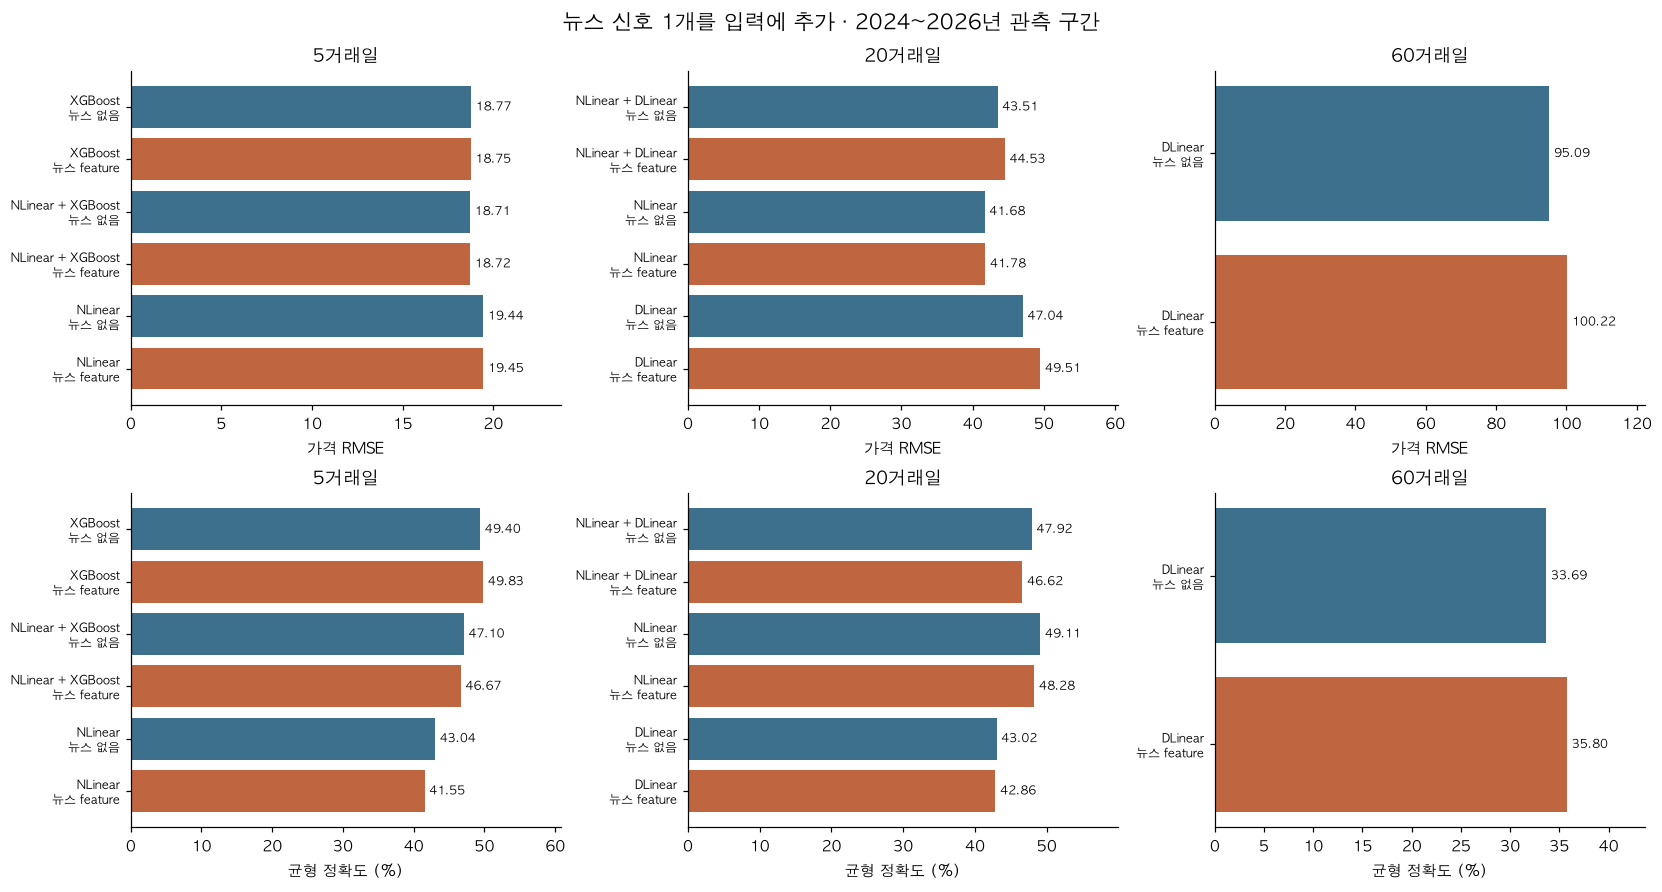

In [6]:
effect_rows,comparison_rows,interval_rows=[],[],[]
for h,members in PAIRS.items():
    table=forecasts.loc[forecasts.horizon.eq(h)]
    def get_prediction(name,mode):
        return table.loc[table.model.eq(name)&table["mode"].eq(mode)].set_index("origin_date").sort_index()
    def compare(candidate,reference):
        pd.testing.assert_frame_equal(candidate[["actual_return","current_price","target_date"]],reference[["actual_return","current_price","target_date"]])
        a=scores(candidate,candidate.predicted_return);b=scores(reference,reference.predicted_return)
        return {"추가 후 RMSE":a["가격 RMSE"],"비교 RMSE":b["가격 RMSE"],"RMSE 개선 (%)":100*(1-a["가격 RMSE"]/b["가격 RMSE"]),
            "방향 변화 (pp)":a["방향 적중률 (%)"]-b["방향 적중률 (%)"],
            "균형 변화 (pp)":a["균형 정확도 (%)"]-b["균형 정확도 (%)"]}
    for name in table.model.unique():
        a,b=get_prediction(name,"뉴스 feature"),get_prediction(name,"뉴스 없음")
        for year,mask in [("전체",np.ones(len(a),bool)),*[(str(y),a.index.year==y) for y in (2024,2025,2026)]]:
            if mask.any():effect_rows.append({"연도":year,"지평":h,"모델":name,**compare(a.loc[mask],b.loc[mask])})
    target=" + ".join(members)
    missing=get_prediction(target,"뉴스 feature");base_missing=get_prediction(target,"뉴스 없음")
    absent=~missing.news_used
    np.testing.assert_array_equal(missing.loc[absent,"predicted_return"],base_missing.loc[absent,"predicted_return"])
    candidate=get_prediction(target,"뉴스 feature")
    comparators=[(target,"뉴스 없음"),*[(m,mode) for m in members if m!=target for mode in MODES.values()]]
    for name,mode in comparators:
        reference=get_prediction(name,mode)
        comparison_rows.append({"지평":h,"지정 조합":target,"비교 모델":name,"비교 입력":mode,**compare(candidate,reference)})
        assert candidate.index.equals(coffee_sessions(candidate.index.min(),candidate.index.max()))
        for block in (h,2*h):
            interval_rows.append({"지평":h,"지정 조합":target,"비교 모델":name,"비교 입력":mode,"블록":block,
                **paired_interval(candidate,candidate.predicted_return,reference.predicted_return,block)})
effects=pd.DataFrame(effect_rows);comparisons=pd.DataFrame(comparison_rows);intervals=pd.DataFrame(interval_rows)
show(effects.loc[effects["연도"].eq("전체")]);show(comparisons);show(intervals)
active_rows=[]
for (h,name,mode),g in forecasts.groupby(["horizon","model","mode"]):
    active=news_feature.reindex(g.origin_date).fillna(0).ne(0).to_numpy()
    for label,mask in (("방향 뉴스 있음",active),("방향 뉴스 없음",~active)):
        if mask.any():active_rows.append({"지평":h,"모델":name,"입력":mode,"구간":label,**scores(g.loc[mask],g.predicted_return.loc[mask])})
active_metrics=pd.DataFrame(active_rows)
show(active_metrics)
fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
for column,h in enumerate(PAIRS):
    table=metrics.loc[metrics["연도"].eq("전체")&metrics["지평"].eq(h)]
    labels=[f"{row['모델']}\n{row['입력']}" for row in table.to_dict("records")]
    for ax,metric in zip(axes[:,column],["가격 RMSE","균형 정확도 (%)"]):
        bars=ax.barh(range(len(table)),table[metric],color=["#BF653F" if mode=="뉴스 feature" else "#3D708C" for mode in table["입력"]])
        ax.set(yticks=range(len(table)),yticklabels=labels,xlabel=metric,title=f"{h}거래일")
        ax.tick_params(axis="y",labelsize=8);ax.bar_label(bars,fmt="%.2f",padding=3,fontsize=8)
        ax.set_xlim(0,table[metric].max()*1.22)
fig.suptitle("뉴스 신호 1개를 입력에 추가 · 2024~2026년 관측 구간",fontsize=14)
plt.show()

## 6. 실행 검사·저장·해석

원본 가격·뉴스 SHA, 코드·라이브러리 버전, 고정 설정과 Validation 선택, 학습 모델·입력 표준화, 전체 예측·연도별 지표·뉴스 대조를 저장한다. 실제 모델 입력은 가격+기후+거시 27개와 뉴스 feature 하나다. 원자료 모든 컬럼을 사용하는 것은 아니다. 같은 run을 재실행했을 때 산출물이 다르면 충돌로 중단한다.

In [7]:
assert not forecasts.duplicated(["horizon","model","mode","origin_date"]).any()
assert not forecasts.model.str.contains("Persistence|Naive",regex=True).any()
assert forecasts.target_date.le(prices.close.dropna().index.max()).all()
assert forecasts.origin_date.dt.year.isin([2024,2025,2026]).all()
assert protocol_path.read_text()==serialized
probe=news_sessions[:40];boundary=probe[-1].tz_localize("UTC")+pd.Timedelta(hours=23)
earlier=[r for r in records if pd.Timestamp(r["event_at"])<=boundary and pd.Timestamp(r["selection_available_at"])<=boundary]
pd.testing.assert_frame_equal(daily_news_feature(earlier,probe,availability="research"),daily.loc[probe])
for filename,frame in {"individual_predictions.parquet":individual,"ensemble_predictions.parquet":forecasts,
    "validation_predictions.parquet":validation_individual,"metrics.csv":metrics,"effects.csv":effects,
    "comparisons.csv":comparisons,"validation.csv":validation,"setting_metrics.csv":setting_metrics,
    "intervals.csv":intervals,"active_metrics.csv":active_metrics,
    "daily_news.parquet":daily.reset_index(names="date"),"feature_audit.csv":feature_audit,"news_audit.csv":news_audit}.items():
    path=OUTPUT/filename
    if path.suffix==".parquet":
        if path.exists():pd.testing.assert_frame_equal(pd.read_parquet(path),frame,check_exact=True)
        else:frame.to_parquet(path,index=False)
    else:
        content=frame.to_csv(index=False)
        if path.exists():assert path.read_text()==content,f"재실행 값 충돌: {filename}"
        else:path.write_text(content)
print("검사 통과 및 저장:",OUTPUT.relative_to(ROOT))
for h,members in PAIRS.items():
    target=" + ".join(members)
    row=effects.loc[effects["연도"].eq("전체")&effects["지평"].eq(h)&effects["모델"].eq(target)].iloc[0]
    choice=selection.loc[selection["지평"].eq(h)].iloc[0]
    display(Markdown(f"**{h}일 지정 조합 {target}:** 뉴스 feature 추가 후 RMSE {row['추가 후 RMSE']:.4f}; "
        f"같은 조합의 뉴스 없는 모델 대비 RMSE 개선 {row['RMSE 개선 (%)']:+.2f}%, 균형 변화 {row['균형 변화 (pp)']:+.2f}pp. "
        f"Validation 선택은 **{choice['모델']} / {choice['입력']}**이며 평가 결과로 다시 선택하지 않았다."))
display(Markdown("기간별 개선 방향·구성 단일 모델 대조·블록 구간을 함께 읽는다. "
    "소급 분류·제목만 있는 기사·기간별 기사 선정 수 차이·적은 학습 표본·한 seed라는 한계가 있다. "
    "이전 2015년부터 학습한 모델과 이번 2022년부터 학습한 모델의 차이를 뉴스 feature 효과로 해석하지 않는다."))

검사 통과 및 저장: data/processed/news_feature_ensemble/ed374e9c9c0a19c6


**5일 지정 조합 NLinear + XGBoost:** 뉴스 feature 추가 후 RMSE 18.7214; 같은 조합의 뉴스 없는 모델 대비 RMSE 개선 -0.05%, 균형 변화 -0.43pp. Validation 선택은 **XGBoost / 뉴스 feature**이며 평가 결과로 다시 선택하지 않았다.

**20일 지정 조합 NLinear + DLinear:** 뉴스 feature 추가 후 RMSE 44.5332; 같은 조합의 뉴스 없는 모델 대비 RMSE 개선 -2.35%, 균형 변화 -1.30pp. Validation 선택은 **DLinear / 뉴스 없음**이며 평가 결과로 다시 선택하지 않았다.

**60일 지정 조합 DLinear:** 뉴스 feature 추가 후 RMSE 100.2179; 같은 조합의 뉴스 없는 모델 대비 RMSE 개선 -5.40%, 균형 변화 +2.12pp. Validation 선택은 **DLinear / 뉴스 feature**이며 평가 결과로 다시 선택하지 않았다.

기간별 개선 방향·구성 단일 모델 대조·블록 구간을 함께 읽는다. 소급 분류·제목만 있는 기사·기간별 기사 선정 수 차이·적은 학습 표본·한 seed라는 한계가 있다. 이전 2015년부터 학습한 모델과 이번 2022년부터 학습한 모델의 차이를 뉴스 feature 효과로 해석하지 않는다.